Tiene una base de datos preprocesada ya.
1. Cargar los datos

In [2]:
import pandas as pd
import lxml
import numpy as np
import json
import seaborn as sns
import matplotlib.pyplot as plt

1. Cargamos el archivo diccionario

In [3]:
# Cargamos el archivo para tener los nombres reales
df_diccionario = pd.read_csv("data_dictionary/BPS_pathologies_gen3.csv")

# Nos aseguramos de que el código BPS sea tratado como texto (string)
# y que tenga ceros a la izquierda (ej: '401' pasa a ser '0401')
df_diccionario['CODE_BPS'] = df_diccionario['CODE_BPS'].astype(str).str.zfill(4)

# Creamos un diccionario rápido de Python para traducir: { 'Código': 'Nombre en inglés' }
traductor_enfermedades = dict(zip(df_diccionario['CODE_BPS'], df_diccionario['BPS_PATHOLOGY']))

2. Cargamos los datos 

In [4]:
ruta_nombre_archivo_json = "data/daae_generated_diabetes_patients_camda_gen3_preprocessed.json"

print("Cargando el archivo JSON... ")
with open(ruta_nombre_archivo_json, 'r') as f:
    datos_json = json.load(f)

registros_limpios = []

print("Procesando los historiales de los pacientes...")
for paciente_id, visitas in datos_json.items():
    # El sexo siempre está en la primera lista/visita
    codigo_sexo = visitas[0][0]
    sexo = "Mujer" if codigo_sexo == "2222" else "Hombre"
    
    # Recorremos el resto de visitas (de la segunda en adelante)
    # Recorremos el resto de visitas (de la segunda en adelante)
    for visita in visitas[1:]:
        # La edad DEBE empezar por 9 Y tener exactamente 4 caracteres (ej: "9070")
        edad_codigo = [c for c in visita if c.startswith("9") and len(str(c)) == 4]
        
        if edad_codigo:
            # Calculamos la edad real de forma segura
            edad = int(edad_codigo[0]) - 9000
            
            # Las enfermedades serán todo lo que NO sea el código de edad de 4 dígitos
            enfermedades = [c for c in visita if c != edad_codigo[0]]
            
            for enf in enfermedades:
                enf_4digitos = str(enf).zfill(4)
                nombre_enfermedad = traductor_enfermedades.get(enf_4digitos, f"Desconocido ({enf_4digitos})")
                
                registros_limpios.append({
                    "Paciente_ID": paciente_id,
                    "Sexo": sexo,
                    "Edad_Diagnostico": edad, # Ahora la edad será 100% real (entre 0 y 120)
                    "Codigo_Enfermedad": enf_4digitos,
                    "Nombre_Enfermedad": nombre_enfermedad
                })

# Convertimos la lista de registros en un DataFrame gigante de Pandas
df_pacientes = pd.DataFrame(registros_limpios)
print("¡Proceso completado! Tabla 'df_pacientes' creada con éxito.\n")

Cargando el archivo JSON... 
Procesando los historiales de los pacientes...
¡Proceso completado! Tabla 'df_pacientes' creada con éxito.



- ANÁLISIS EXPLORATIORIO

In [18]:
print("--- MUESTRA DE LA TABLA PROCESADA ---")
print(df_pacientes.head(10))
print("\n" + "="*50 + "\n")

print("Número total de registros procesados:", len(df_pacientes))
print("Número total de pacientes únicos:", df_pacientes['Paciente_ID'].nunique())

df_unique_patients = df_pacientes.drop_duplicates(subset='Paciente_ID')
print("Número total de pacientes únicos (verificado):", len(df_unique_patients))

--- MUESTRA DE LA TABLA PROCESADA ---
  Paciente_ID   Sexo  Edad_Diagnostico Codigo_Enfermedad  \
0           0  Mujer                70              0913   
1           0  Mujer                70              0401   
2           0  Mujer                72              1302   
3           0  Mujer                74              1401   
4           0  Mujer                75              0402   
5           0  Mujer                78              0507   
6           0  Mujer                80              0506   
7           0  Mujer                80              0212   
8           1  Mujer                47              1302   
9           1  Mujer                57              0913   

        Nombre_Enfermedad  
0            Hypertension  
1                Diabetes  
2   Arthrosis/spondylosis  
3  Chronic kidney disease  
4         Hyperlipidaemia  
5        Anxiety disorder  
6           Mood disorder  
7         Cervical cancer  
8   Arthrosis/spondylosis  
9            Hyperten

In [13]:
# 1. Conteo de Hombres vs Mujeres en tus datos
print("Distribucion de pacientes por sexo:")
print(df_unique_patients['Sexo'].value_counts())
print ("\n")


Distribucion de pacientes por sexo:
Sexo
Hombre    640826
Mujer     279347
Name: count, dtype: int64




Análisis estadístico de nuestra variable numérica: EDAD

In [ ]:
resumen_por_sexo = df_unique_patients.groupby('Sexo')['Edad_Diagnostico'].describe()

# 2. Resumen estadístico General (Total)
resumen_total = pd.DataFrame(df_unique_patients['Edad_Diagnostico'].describe()).T
resumen_total.index = ['Total']

# 3. Concatenamos ambas tablas
tabla_final = pd.concat([resumen_por_sexo, resumen_total])

# 4. Ponemos la tabla (redondeos y enteros para el conteo)
tabla_final = tabla_final.round(1)
tabla_final['count'] = tabla_final['count'].astype(int)

print("="*60)
print(" RESUMEN ESTADÍSTICO DE EDAD (POR PACIENTE ÚNICO REAL) ")
print("="*60)
print(tabla_final)
print("\n" + "-"*60 + "\n")


# 5. Calculamos las modas reales por sexo en la población única
# Mostraria las edades de inicio más frecuentes por sexo
print("Edades de inicio más frecuentes por sexo (Modas Reales):")
for sexo in df_unique_patients['Sexo'].unique():
    moda_sexo = df_unique_patients[df_unique_patients['Sexo'] == sexo]['Edad_Diagnostico'].mode()[0]
    if sexo == "Mujer":
        print(f" -> Mujeres: {int(moda_sexo)} años")
    else:
        print(f" -> Hombres: {int(moda_sexo)} años")

 RESUMEN ESTADÍSTICO DE EDAD (POR PACIENTE ÚNICO REAL) 
         count  mean   std  min   25%   50%   75%    max
Hombre  640826  57.6  12.3  0.0  49.0  58.0  66.0  110.0
Mujer   279347  60.9  13.7  0.0  53.0  62.0  70.0  110.0
Total   920173  58.6  12.8  0.0  50.0  60.0  68.0  110.0

------------------------------------------------------------

Edades de inicio más frecuentes por sexo (Modas Reales):
 -> Mujeres: 68 años
 -> Hombres: 48 años


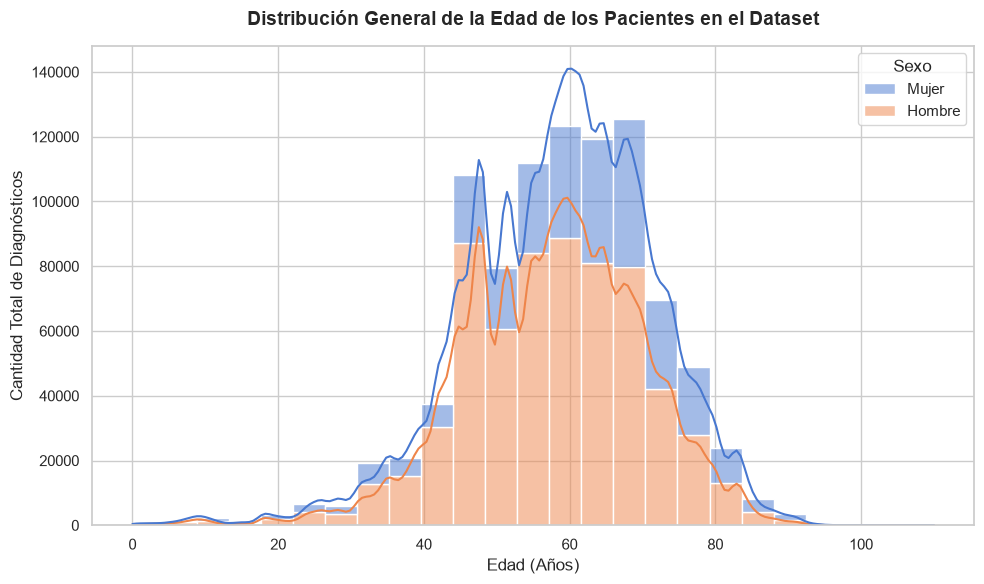

In [21]:
plt.figure(figsize=(10, 6))

# 2. Elegimos un estilo visual limpio y bonito
sns.set_theme(style="whitegrid")

# 3. Creamos el gráfico de distribución de edad
# Usamos 'kde=True' para que dibuje la línea suave de la tendencia
# Usamos 'hue='Sexo'' para que pinte las barras de hombres y mujeres por separado y poder compararlos
sns.histplot(
    data=df_unique_patients, 
    x='Edad_Diagnostico', 
    hue='Sexo', 
    multiple='stack',   # Apila las barras de hombre/mujer para ver también el total combinado
    bins=25,            # Número de barras en las que dividimos la edad
    kde=True,           # Dibuja la curva de densidad suave
    palette='muted'     # Paleta de colores suaves y profesionales
)

# 4. Añadimos las etiquetas de los ejes y el título en español
plt.title('Distribución General de la Edad de los Pacientes en el Dataset', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Edad (Años)', fontsize=12)
plt.ylabel('Cantidad Total de Diagnósticos', fontsize=12)

# 5. Ajustamos los márgenes para que no se corte nada y lo mostramos
plt.tight_layout()
plt.show()



Análisis descriptivo de la variable categórica: Enfermedad

In [24]:
# 2. Las 10 enfermedades más comunes en tu dataset
print("Top 10 enfermedades más comunes:")
top_10 = df_pacientes['Nombre_Enfermedad'].value_counts().head(10)
print(top_10)

Top 10 enfermedades más comunes:
Nombre_Enfermedad
Diabetes                  899883
Hypertension              694489
Hyperlipidaemia           558800
Arthrosis/spondylosis     454434
Anxiety disorder          199217
Heart failure             139045
Obesity                   121356
COPD                      120775
Atrial fibrillation        92269
Ischemic heart disease     86850
Name: count, dtype: int64


In [ ]:
#TOP 5 enfermedades más comunes por sexo

for sexo in df_pacientes['Sexo'].unique():
    print(f"\n--- TOP 5: {sexo.upper()} ---")
    df_sexo = df_pacientes[df_pacientes['Sexo'] == sexo]
    total_sexo = df_sexo['Paciente_ID'].nunique()
    
    top_s = df_sexo['Nombre_Enfermedad'].value_counts().head(5).reset_index()
    top_s.columns = ['Enfermedad', 'Pacientes']
    top_s['Prevalencia (%)'] = (top_s['Pacientes'] / total_sexo) * 100
    print(top_s.to_string(index=False))

print("\n" + "-"*60 + "\n")




--- TOP 5: MUJER ---
           Enfermedad  Pacientes  Prevalencia (%)
             Diabetes     279347       100.000000
         Hypertension     225825        80.840317
Arthrosis/spondylosis     190204        68.088793
      Hyperlipidaemia     178487        63.894368
     Anxiety disorder      90459        32.382306

--- TOP 5: HOMBRE ---
           Enfermedad  Pacientes  Prevalencia (%)
             Diabetes     620536        96.833774
         Hypertension     468664        73.134361
      Hyperlipidaemia     380313        59.347311
Arthrosis/spondylosis     264230        41.232722
     Anxiety disorder     108758        16.971534

------------------------------------------------------------



¿?En teoria el 100% de los pacientes tienen diabetes, pero en el dataset hay un 3% de hombres que no la tienen.
Esto puede ser un error en la generación de los datos sintéticos o una característica específica del dataset.

         ESTADÍSTICAS DE COMORBILIDAD
count    920173.000000
mean          4.702135
std           2.399468
min           1.000000
25%           3.000000
50%           4.000000
75%           6.000000
max          30.000000
Name: Codigo_Enfermedad, dtype: float64


/tmp/ipykernel_107961/2302449063.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=carga_enfermedades, palette='Blues_r')


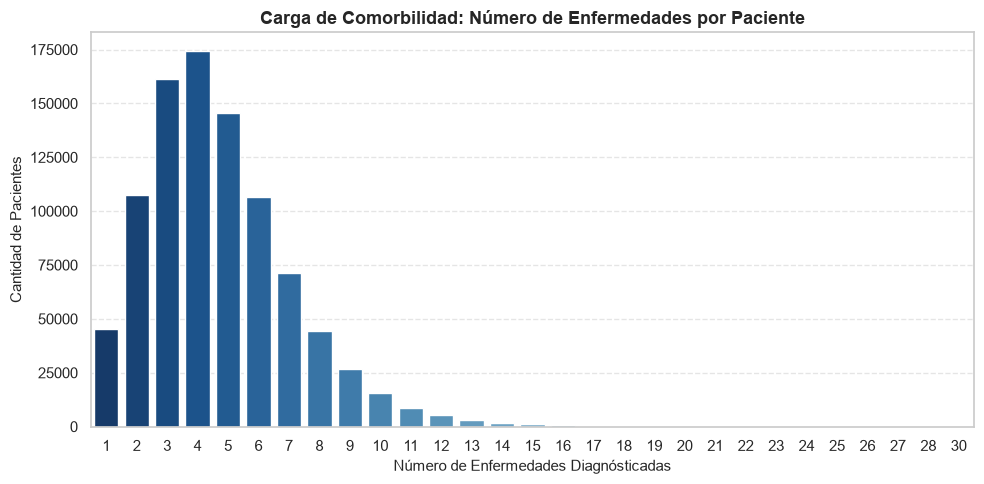

In [33]:
#Análisis de Carga de Comorbilidad (¿Cuántas enfermedades tienen?)
carga_enfermedades = df_pacientes.groupby('Paciente_ID')['Codigo_Enfermedad'].count()

print("="*60)
print("         ESTADÍSTICAS DE COMORBILIDAD")
print("="*60)
print(carga_enfermedades.describe())


# =====================================================================
# VISUALIZACIÓN: Gráfico de barras de la Carga de Comorbilidad
# =====================================================================
plt.figure(figsize=(10, 5))
sns.countplot(x=carga_enfermedades, palette='Blues_r')

plt.title('Carga de Comorbilidad: Número de Enfermedades por Paciente', fontsize=13, fontweight='bold')
plt.xlabel('Número de Enfermedades Diagnósticadas', fontsize=11)
plt.ylabel('Cantidad de Pacientes', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

De media por paciente tienen cuatro enfermedades diagnósticadas

- ANÁLISIS ENDPOINTS

In [34]:
# 1. Definimos los 4 códigos oficiales del challenge
endpoints = {
    "0703": "Retinopatía diabética (Ceguera)",
    "1401": "Enfermedad Renal Crónica (Riñón)",
    "0910": "Cardiopatía Isquémica (Corazón)",
    "1999": "Amputaciones"
}

# 2. Calculamos los totales de referencia de pacientes únicos por sexo
total_pacientes_gen = df_pacientes.groupby('Paciente_ID')['Sexo'].first()
n_hombres = (total_pacientes_gen == 'Hombre').sum()
n_mujeres = (total_pacientes_gen == 'Mujer').sum()
n_total = len(total_pacientes_gen)

print("="*75)
print("   ESTUDIO DE PREVALENCIA DE ENDPOINTS (COMPLICACIONES DE LA DIABETES)")
print("="*75)

# Creamos una lista para guardar los resultados y hacer luego una tabla limpia
resultados_endpoints = []

for codigo, nombre in endpoints.items():
    # Filtramos las filas que tengan esta complicación
    df_complicacion = df_pacientes[df_pacientes['Codigo_Enfermedad'] == codigo]
    
    # Agrupamos por paciente único para saber el sexo de quienes la sufren
    pacientes_afectados = df_complicacion.groupby('Paciente_ID')['Sexo'].first()
    
    # Contamos por sexo
    casos_hombres = (pacientes_afectados == 'Hombre').sum()
    casos_mujeres = (pacientes_afectados == 'Mujer').sum()
    casos_total = len(pacientes_afectados)
    
    # Calculamos porcentajes reales sobre sus respectivas poblaciones
    pct_hombres = (casos_hombres / n_hombres) * 100 if n_hombres > 0 else 0
    pct_mujeres = (casos_mujeres / n_mujeres) * 100 if n_mujeres > 0 else 0
    pct_total = (casos_total / n_total) * 100 if n_total > 0 else 0
    
    # Guardamos los datos para la tabla
    resultados_endpoints.append({
        "Complicación": nombre,
        "Código": codigo,
        "Casos Hombres": f"{casos_hombres} ({pct_hombres:.2f}%)",
        "Casos Mujeres": f"{casos_mujeres} ({pct_mujeres:.2f}%)",
        "Total General": f"{casos_total} ({pct_total:.2f}%)",
        "Total_Num": casos_total # Guardamos el número puro para el análisis posterior
    })

# 3. Convertimos en DataFrame de Pandas para mostrarlo impecable
df_resultados_endpoints = pd.DataFrame(resultados_endpoints)
print(df_resultados_endpoints.drop(columns=['Total_Num']).to_string(index=False))
print("="*75)

   ESTUDIO DE PREVALENCIA DE ENDPOINTS (COMPLICACIONES DE LA DIABETES)
                    Complicación Código Casos Hombres  Casos Mujeres Total General
 Retinopatía diabética (Ceguera)   0703 50161 (7.83%) 29754 (10.65%) 79915 (8.68%)
Enfermedad Renal Crónica (Riñón)   1401 53062 (8.28%)  22572 (8.08%) 75634 (8.22%)
 Cardiopatía Isquémica (Corazón)   0910 61320 (9.57%)  25530 (9.14%) 86850 (9.44%)
                    Amputaciones   1999     0 (0.00%)      0 (0.00%)     0 (0.00%)


Ejemplo: Enfermedad Renal Crónica 


  ¿CUÁNTOS AÑOS TARDAN EN DESARROLLAR LA ENFERMEDAD RENAL?
          count  mean  std   min  25%  50%   75%   max
Sexo                                                  
Hombre  51260.0   5.7  6.5 -51.0  1.0  5.0  10.0  77.0
Mujer   22572.0   7.0  6.9 -49.0  2.0  6.0  11.0  85.0


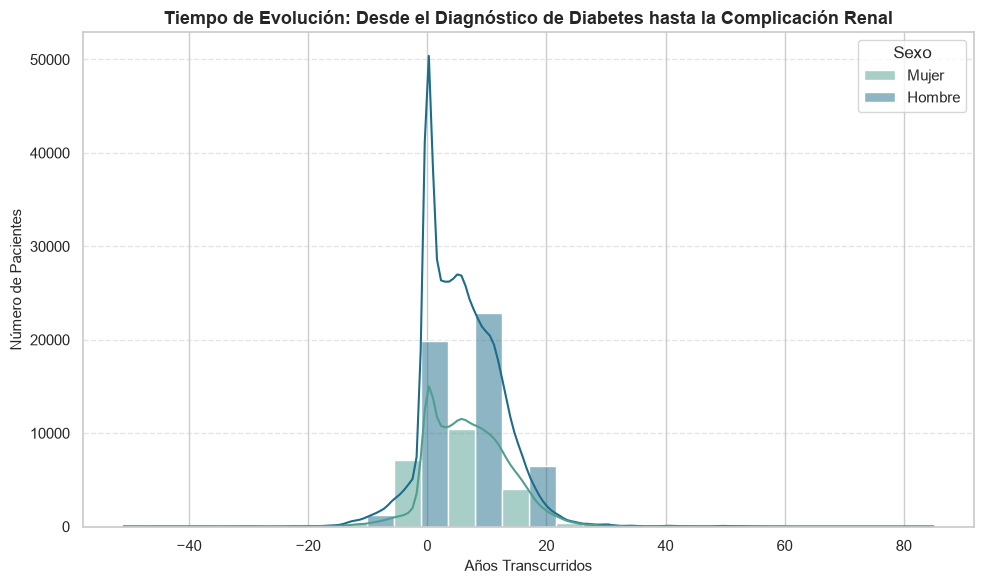

In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Obtenemos la edad de debut de la Diabetes (0401) por paciente
df_diabetes = df_pacientes[df_pacientes['Codigo_Enfermedad'] == '0401']
edad_diabetes = df_diabetes.groupby('Paciente_ID')['Edad_Diagnostico'].min().rename('Edad_Diabetes')

# 2. Obtenemos la edad de aparición del fallo Renal (1401) por paciente
df_rinon = df_pacientes[df_pacientes['Codigo_Enfermedad'] == '1401']
edad_rinon = df_rinon.groupby('Paciente_ID')['Edad_Diagnostico'].min().rename('Edad_Rinon')

# 3. Cruzamos los datos de los pacientes que tienen AMBAS enfermedades
df_temporal = pd.merge(edad_diabetes, edad_rinon, on='Paciente_ID', how='inner')

# Extraemos también el Sexo para poder comparar hombres y mujeres
sexo_pacientes = df_pacientes.groupby('Paciente_ID')['Sexo'].first()
df_temporal = df_temporal.join(sexo_pacientes)

# 4. Calculamos los años que pasan entre un diagnóstico y otro
df_temporal['Anios_Hasta_Complicacion'] = df_temporal['Edad_Rinon'] - df_temporal['Edad_Diabetes']


print("\n" + "="*60)
print("  ¿CUÁNTOS AÑOS TARDAN EN DESARROLLAR LA ENFERMEDAD RENAL?")
print("="*60)
resumen_tiempo = df_temporal.groupby('Sexo')['Anios_Hasta_Complicacion'].describe().round(1)
print(resumen_tiempo)
print("="*60)

# Visualizacion de la distribución del tiempo hasta la complicación renal
plt.figure(figsize=(10, 6))

# Pintamos la distribución del tiempo hasta el evento
sns.histplot(
    data=df_temporal, 
    x='Anios_Hasta_Complicacion', 
    hue='Sexo', 
    multiple='dodge', 
    kde=True, 
    bins=15,
    palette='crest'
)

plt.title('Tiempo de Evolución: Desde el Diagnóstico de Diabetes hasta la Complicación Renal', fontsize=13, fontweight='bold')
plt.xlabel('Años Transcurridos', fontsize=11)
plt.ylabel('Número de Pacientes', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

A los hombres en riñon les tarda unos ~6 años en aparecer la enfermedad, y a las mujeres a los 7

 Cardiopatía Isquémica (Corazón)


  ¿CUÁNTOS AÑOS TARDAN EN DESARROLLAR LA ENFERMEDAD?
          count  mean  std   min  25%  50%  75%   max
Sexo                                                 
Hombre  59932.0   1.4  6.5 -59.0 -1.0  0.0  5.0  59.0
Mujer   25530.0   1.6  7.0 -56.0 -1.0  0.0  5.0  56.0


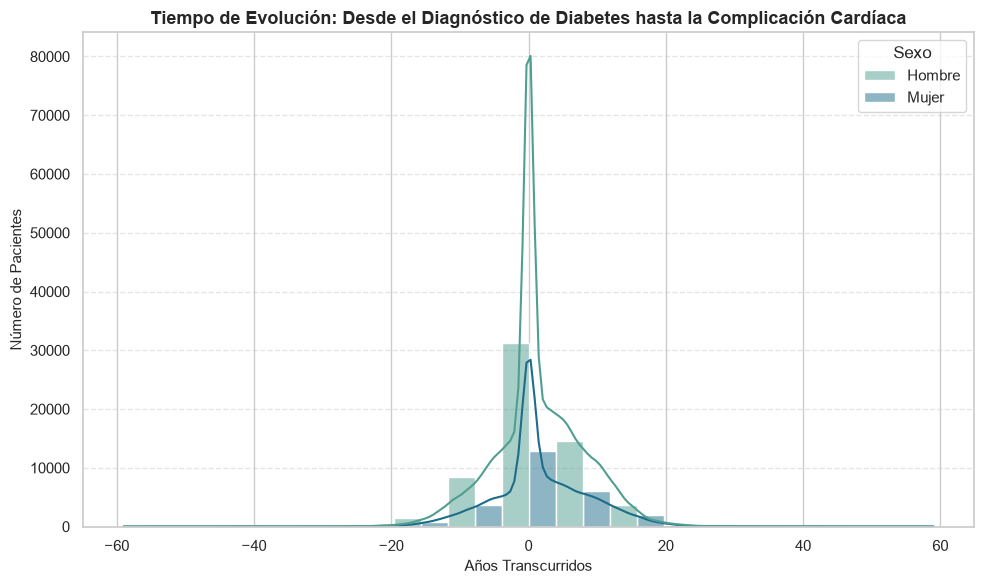

In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Obtenemos la edad de debut de la Diabetes (0401) por paciente
df_diabetes = df_pacientes[df_pacientes['Codigo_Enfermedad'] == '0401']
edad_diabetes = df_diabetes.groupby('Paciente_ID')['Edad_Diagnostico'].min().rename('Edad_Diabetes')

# 2. Obtenemos la edad de aparición del  Cardiopatía Isquémica (Corazón) (0910) por paciente
df_corazon = df_pacientes[df_pacientes['Codigo_Enfermedad'] == '0910']
edad_corazon = df_corazon.groupby('Paciente_ID')['Edad_Diagnostico'].min().rename('Edad_Corazon')

# 3. Cruzamos los datos de los pacientes que tienen AMBAS enfermedades
df_temporal = pd.merge(edad_diabetes, edad_corazon, on='Paciente_ID', how='inner')

# Extraemos también el Sexo para poder comparar hombres y mujeres
sexo_pacientes = df_pacientes.groupby('Paciente_ID')['Sexo'].first()
df_temporal = df_temporal.join(sexo_pacientes)

# 4. Calculamos los años que pasan entre un diagnóstico y otro
df_temporal['Anios_Hasta_Complicacion'] = df_temporal['Edad_Corazon'] - df_temporal['Edad_Diabetes']


print("\n" + "="*60)
print("  ¿CUÁNTOS AÑOS TARDAN EN DESARROLLAR LA ENFERMEDAD?")
print("="*60)
resumen_tiempo = df_temporal.groupby('Sexo')['Anios_Hasta_Complicacion'].describe().round(1)
print(resumen_tiempo)
print("="*60)

# Visualizacion de la distribución del tiempo hasta la complicación renal
plt.figure(figsize=(10, 6))

# Pintamos la distribución del tiempo hasta el evento
sns.histplot(
    data=df_temporal, 
    x='Anios_Hasta_Complicacion', 
    hue='Sexo', 
    multiple='dodge', 
    kde=True, 
    bins=15,
    palette='crest'
)

plt.title('Tiempo de Evolución: Desde el Diagnóstico de Diabetes hasta la Complicación Cardíaca', fontsize=13, fontweight='bold')
plt.xlabel('Años Transcurridos', fontsize=11)
plt.ylabel('Número de Pacientes', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Muy poco tiempo desde la aparicion de diabetes hata el problema en el corazon. Hombres y mujeres distancia muy similar.

Retinopatía diabética (Ceguera)


  ¿CUÁNTOS AÑOS TARDAN EN DESARROLLAR LA ENFERMEDAD?
          count  mean  std   min  25%  50%  75%   max
Sexo                                                 
Hombre  47374.0   4.1  6.3 -64.0  0.0  3.0  8.0  68.0
Mujer   29754.0   4.7  6.9 -65.0  0.0  4.0  9.0  58.0


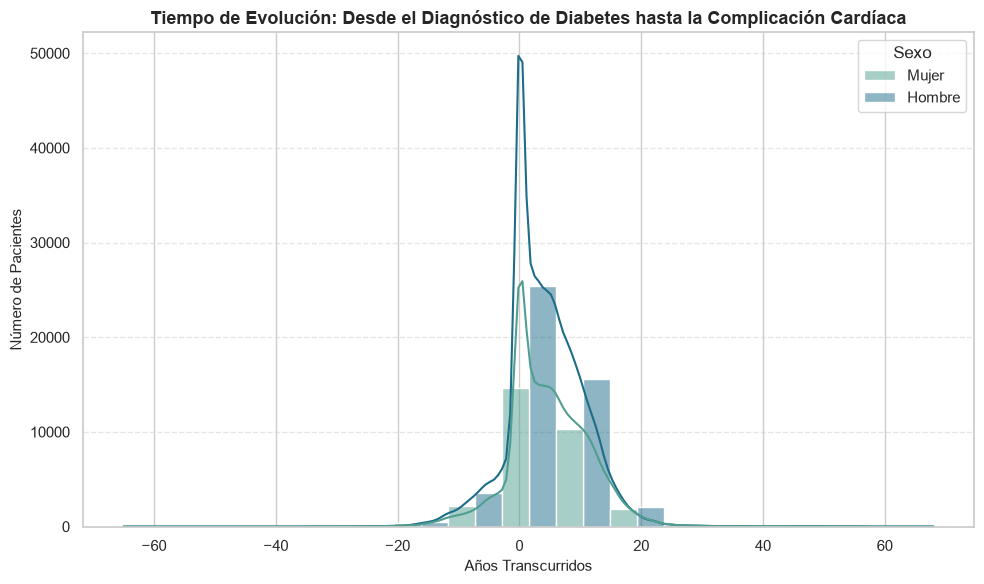

In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Obtenemos la edad de debut de la Diabetes (0401) por paciente
df_diabetes = df_pacientes[df_pacientes['Codigo_Enfermedad'] == '0401']
edad_diabetes = df_diabetes.groupby('Paciente_ID')['Edad_Diagnostico'].min().rename('Edad_Diabetes')

# 2. Obtenemos la edad de aparición de la Retinopatía diabética (Ceguera) (0703) por paciente
df_retinopatia = df_pacientes[df_pacientes['Codigo_Enfermedad'] == '0703']
edad_retinopatia = df_retinopatia.groupby('Paciente_ID')['Edad_Diagnostico'].min().rename('Edad_Retinopatia')

# 3. Cruzamos los datos de los pacientes que tienen AMBAS enfermedades
df_temporal = pd.merge(edad_diabetes, edad_retinopatia, on='Paciente_ID', how='inner')

# Extraemos también el Sexo para poder comparar hombres y mujeres
sexo_pacientes = df_pacientes.groupby('Paciente_ID')['Sexo'].first()
df_temporal = df_temporal.join(sexo_pacientes)

# 4. Calculamos los años que pasan entre un diagnóstico y otro
df_temporal['Anios_Hasta_Complicacion'] = df_temporal['Edad_Retinopatia'] - df_temporal['Edad_Diabetes']


print("\n" + "="*60)
print("  ¿CUÁNTOS AÑOS TARDAN EN DESARROLLAR LA ENFERMEDAD?")
print("="*60)
resumen_tiempo = df_temporal.groupby('Sexo')['Anios_Hasta_Complicacion'].describe().round(1)
print(resumen_tiempo)
print("="*60)

# Visualizacion de la distribución del tiempo hasta la complicación renal
plt.figure(figsize=(10, 6))

# Pintamos la distribución del tiempo hasta el evento
sns.histplot(
    data=df_temporal, 
    x='Anios_Hasta_Complicacion', 
    hue='Sexo', 
    multiple='dodge', 
    kde=True, 
    bins=15,
    palette='crest'
)

plt.title('Tiempo de Evolución: Desde el Diagnóstico de Diabetes hasta la Complicación Cardíaca', fontsize=13, fontweight='bold')
plt.xlabel('Años Transcurridos', fontsize=11)
plt.ylabel('Número de Pacientes', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Desde que se diagnostica la diabetes, tarda unos 4.5 años en desarrollar ceguera para hombres y mujeres. 